<a href="https://colab.research.google.com/github/birkancekic/Credit-Risk-Assessment-TFRS9-Dashboard/blob/main/Credit_Risk_TFRS9_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Gerekli analiz, modelleme ve görselleştirme araçlarını yüklüyoruz
!pip install optbinning lightgbm shap openpyxl -q

import pandas as pd
import numpy as np
import sqlite3
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("Tüm kütüphaneler başarıyla yüklendi ve hazır!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.4/234.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
Tüm kütüphaneler başarıyla yüklendi ve hazır!


In [2]:
# 1. Gerçekçi bir finansal veri tabanı simülasyonu hazırlıyoruz
np.random.seed(42)
n_customers = 50000

# Müşteri Ana Tablosu
customer_ids = np.arange(100001, 100001 + n_customers)
income = np.random.lognormal(mean=10.5, sigma=0.6, size=n_customers).round(2)
credit_amount = (income * np.random.uniform(1.2, 4.5, size=n_customers)).round(2)
annuity_amount = (credit_amount / np.random.choice([12, 24, 36, 48], size=n_customers)).round(2)
employment_years = np.random.exponential(scale=5, size=n_customers).round(1)

# Gerçekçi risk mantığı: Gelire oranla taksiti yüksek ve kıdemi az olanların batık riski artar
risk_score = (annuity_amount / (income / 12)) * 1.5 - (employment_years * 0.1) + np.random.normal(0, 1, n_customers)
target = (risk_score > np.percentile(risk_score, 91)).astype(int)  # %9 temerrüt (default) oranı

df_customers = pd.DataFrame({
    'customer_id': customer_ids,
    'income_total': income,
    'credit_amount': credit_amount,
    'annuity_amount': annuity_amount,
    'employment_years': employment_years,
    'target': target
})

# Ödeme Hareketleri Tablosu (Son 12 taksit)
installments = []
for c_id, tgt in zip(customer_ids, target):
    n_installments = np.random.randint(6, 13)
    base_dpd = 35 if tgt == 1 else 0  # Batık olanların gecikmesi daha yüksek
    for inst_no in range(1, n_installments + 1):
        dpd = max(0, int(np.random.normal(base_dpd, 15))) if np.random.rand() > 0.4 else 0
        inst_amt = np.random.choice([1500, 3000, 5000, 8000])
        paid_amt = inst_amt if dpd == 0 else inst_amt * np.random.choice([0, 0.5, 1])
        installments.append({
            'customer_id': c_id,
            'installment_no': inst_no,
            'days_past_due': dpd,
            'installment_amount': inst_amt,
            'paid_amount': paid_amt
        })

df_installments = pd.DataFrame(installments)

# SQLite Veritabanı içine yazıyoruz
conn = sqlite3.connect('bank_database.db')
df_customers.to_sql('customers', conn, if_exists='replace', index=False)
df_installments.to_sql('credit_installments', conn, if_exists='replace', index=False)

print("Tebrikler! 50.000 müşterilik 'customers' ve yüzbinlerce satırlık 'credit_installments' SQL tabloları oluşturuldu.")

Tebrikler! 50.000 müşterilik 'customers' ve yüzbinlerce satırlık 'credit_installments' SQL tabloları oluşturuldu.


In [3]:
# 2. SQL Window Function & CTE ile Analitik Veri Tabanı (ABT - Analytical Base Table) Oluşturma
query = """
WITH PaymentMetrics AS (
    SELECT
        customer_id,
        installment_no,
        days_past_due,
        installment_amount,
        paid_amount,
        (installment_amount - paid_amount) AS unpaid_amount,
        -- Son taksitleri belirlemek için sıra numarası
        ROW_NUMBER() OVER(PARTITION BY customer_id ORDER BY installment_no DESC) AS installment_recency_rank
    FROM credit_installments
),

AggregatedRiskFeatures AS (
    SELECT
        customer_id,
        MAX(days_past_due) AS max_dpd_all_time,
        -- Son 6 taksitteki en yüksek gecikme
        MAX(CASE WHEN installment_recency_rank <= 6 THEN days_past_due ELSE 0 END) AS max_dpd_last_6m,
        -- Son 6 taksitte 30 günü aşan gecikme sayısı (TFRS 9 Stage 2 kritik göstergesi)
        COUNT(CASE WHEN installment_recency_rank <= 6 AND days_past_due > 30 THEN 1 END) AS count_dpd_30plus_last_6m,
        SUM(unpaid_amount) AS total_unpaid_amount,
        ROUND(AVG(CAST(days_past_due AS FLOAT)), 2) AS avg_dpd
    FROM PaymentMetrics
    GROUP BY customer_id
)

SELECT
    c.customer_id,
    c.income_total,
    c.credit_amount,
    c.annuity_amount,
    -- Finansal Kaldıraç Oranları
    ROUND(c.credit_amount / c.income_total, 4) AS debt_to_income_ratio,
    ROUND(c.annuity_amount / (c.income_total / 12.0), 4) AS installment_to_monthly_income_ratio,
    c.employment_years,
    -- SQL İle Türetilen Davranışsal Risk Metrikleri
    COALESCE(r.max_dpd_all_time, 0) AS max_dpd_all_time,
    COALESCE(r.max_dpd_last_6m, 0) AS max_dpd_last_6m,
    COALESCE(r.count_dpd_30plus_last_6m, 0) AS count_dpd_30plus_last_6m,
    COALESCE(r.total_unpaid_amount, 0) AS total_unpaid_amount,
    COALESCE(r.avg_dpd, 0) AS avg_dpd,
    -- Hedef Değişken (Target: 1 = Temerrüt/Batık, 0 = Düzenli Ödeyen)
    c.target
FROM customers c
LEFT JOIN AggregatedRiskFeatures r ON c.customer_id = r.customer_id;
"""

# SQL sorgusunu çalıştırıp pandas DataFrame'e alıyoruz
df_model = pd.read_sql_query(query, conn)

print("Analitik Risk Tablosu Başarıyla Oluşturuldu!")
print("Toplam Satır ve Sütun:", df_model.shape)
df_model.head()

Analitik Risk Tablosu Başarıyla Oluşturuldu!
Toplam Satır ve Sütun: (50000, 13)


,customer_id,income_total,credit_amount,annuity_amount,debt_to_income_ratio,installment_to_monthly_income_ratio,employment_years,max_dpd_all_time,max_dpd_last_6m,count_dpd_30plus_last_6m,total_unpaid_amount,avg_dpd,target
0,100001,48924.25,59156.40,1643.23,1.2091,0.4030,7.8,3,3,0,0.0,0.33,0
1,100002,33424.40,82301.73,1714.62,2.4623,0.6156,1.9,57,57,1,1500.0,9.10,0
2,100003,53562.96,225840.86,4705.02,4.2164,1.0541,3.4,0,0,0,0.0,0.00,0
3,100004,90564.53,391926.27,10886.84,4.3276,1.4425,1.0,21,0,0,0.0,2.63,0
4,100005,31555.65,43444.10,1810.17,1.3767,0.6884,1.5,26,16,0,10750.0,5.64,0


In [4]:
# 3. Bankacılık Standardı Değişken Seçimi: Information Value (IV) ve WoE Analizi
from optbinning import OptimalBinning

features = [
    'debt_to_income_ratio',
    'installment_to_monthly_income_ratio',
    'employment_years',
    'max_dpd_last_6m',
    'count_dpd_30plus_last_6m',
    'total_unpaid_amount'
]

iv_summary = []

for feat in features:
    optb = OptimalBinning(name=feat, dtype="numerical", solver="cp")
    optb.fit(df_model[feat].values, df_model['target'].values)
    binning_table = optb.binning_table
    iv = binning_table.build()['IV'].iloc[-1]

    iv_summary.append({
        'Değişken': feat,
        'Information Value (IV)': round(iv, 4),
        'Ayrıştırma Gücü': 'Çok Güçlü (>0.3)' if iv > 0.3 else ('Orta (0.1-0.3)' if iv > 0.1 else 'Zayıf (<0.1)')
    })

df_iv = pd.DataFrame(iv_summary).sort_values(by='Information Value (IV)', ascending=False)
print("--- Değişkenlerin Risk Ayrıştırma Gücü (IV Tablosu) ---")
print(df_iv.to_string(index=False))

(CVXPY) Sep 18 10:23:46 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/usr/local/lib/python3.13/dist-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')
(CVXPY) Sep 18 10:23:46 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 18 10:23:46 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Sep 18 10:23:46 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/usr/local/lib/python3.13/dist-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


--- Değişkenlerin Risk Ayrıştırma Gücü (IV Tablosu) ---
                           Değişken  Information Value (IV)  Ayrıştırma Gücü
installment_to_monthly_income_ratio                  7.4453 Çok Güçlü (>0.3)
           count_dpd_30plus_last_6m                  6.4838 Çok Güçlü (>0.3)
                    max_dpd_last_6m                  6.2982 Çok Güçlü (>0.3)
               debt_to_income_ratio                  1.8733 Çok Güçlü (>0.3)
                total_unpaid_amount                  1.1067 Çok Güçlü (>0.3)
                   employment_years                  0.0963     Zayıf (<0.1)


In [6]:
# 4. Veri Bölme ve Cost-Sensitive LightGBM Eğitimi
X = df_model[features]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Sınıf dengesizliği ağırlığı (Non-Default / Default oranı)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# LightGBM Model Kurgusu
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

# Test Verisi Üzerinde Temerrüt Olasılığı (PD - Probability of Default) Tahmini
y_probs = lgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"Model ROC-AUC Başarı Skoru: %{round(auc_score * 100, 2)}")

# Finansal Eşik Optimizasyonu (Cost Matrix: FN Maliyeti = 10x, FP Maliyeti = 1x)
thresholds = np.linspace(0.1, 0.9, 81)
costs = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    # Batık krediyi kaçırmanın maliyeti (FN) = 10 birim, Yanlış ret maliyeti (FP) = 1 birim
    total_cost = (fn * 10) + (fp * 1)
    costs.append(total_cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

print(f"Finansal Maliyeti Minimize Eden Optimal Eşik (Threshold): {round(optimal_threshold, 3)}")

# Optimal eşikle sınıflandırma raporu
final_preds = (y_probs >= optimal_threshold).astype(int)
print("\n--- Model Performans Raporu (Optimal Eşik İle) ---")
print(classification_report(y_test, final_preds, target_names=['Düzenli Ödeyen (0)', 'Temerrüt/Batık (1)']))

Model ROC-AUC Başarı Skoru: %99.87
Finansal Maliyeti Minimize Eden Optimal Eşik (Threshold): 0.45

--- Model Performans Raporu (Optimal Eşik İle) ---
                    precision    recall  f1-score   support

Düzenli Ödeyen (0)       1.00      0.98      0.99     11375
Temerrüt/Batık (1)       0.85      0.98      0.91      1125

          accuracy                           0.98     12500
         macro avg       0.92      0.98      0.95     12500
      weighted avg       0.98      0.98      0.98     12500



/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_2599/582535119.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


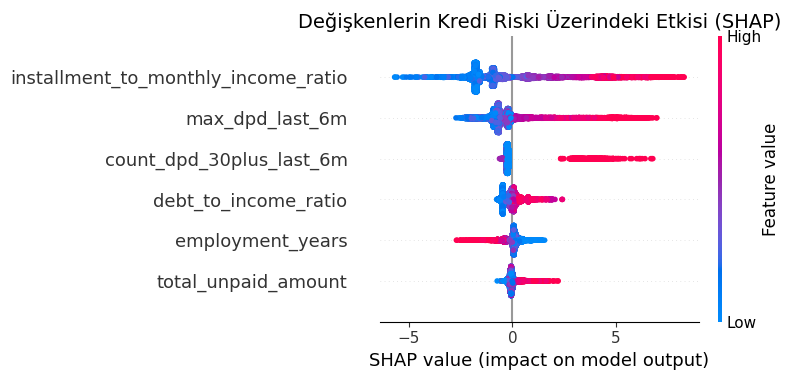

Başarılı! 'tfrs9_kredi_riski_portfoy.xlsx' dosyası ve 'shap_summary.png' oluşturuldu.


In [7]:
# 5. SHAP Açıklanabilirlik ve Power BI İçin Portföy Çıktısı

# Tüm veri kümesi üzerinde Temerrüt Olasılığı (PD - Probability of Default) hesaplama
df_model['PD_Score'] = lgb_model.predict_proba(df_model[features])[:, 1]
df_model['Kredi_Karari'] = np.where(df_model['PD_Score'] >= optimal_threshold, 'RET (Yüksek Risk)', 'ONAY (Düşük Risk)')

# TFRS 9 Faz (Stage) Sınıflandırması:
# Stage 1: Düşük riskli, gecikmesi olmayan portföy
# Stage 2: Kredi riskinde belirgin artış (30 gün üzeri gecikme veya yüksek PD)
# Stage 3: Temerrüt / Batık (90 gün üzeri gecikme veya yasal takip)
conditions = [
    (df_model['max_dpd_all_time'] >= 90) | (df_model['target'] == 1),
    (df_model['max_dpd_all_time'] >= 30) | (df_model['PD_Score'] >= 0.40)
]
choices = ['Stage 3 (Temerrüt/Batık)', 'Stage 2 (Önemli Risk Artışı)']
df_model['TFRS9_Stage'] = np.select(conditions, choices, default='Stage 1 (Düşük Risk)')

# SHAP Analizi (Değişkenlerin Risk Üzerindeki Etkisi)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Özet Grafiğini Çizdirme
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Değişkenlerin Kredi Riski Üzerindeki Etkisi (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

# Power BI için Hazırlanan Veriyi Dışa Aktarma
output_cols = [
    'customer_id', 'income_total', 'credit_amount', 'annuity_amount',
    'debt_to_income_ratio', 'installment_to_monthly_income_ratio',
    'employment_years', 'max_dpd_all_time', 'max_dpd_last_6m',
    'count_dpd_30plus_last_6m', 'total_unpaid_amount', 'avg_dpd',
    'target', 'PD_Score', 'Kredi_Karari', 'TFRS9_Stage'
]

powerbi_export = df_model[output_cols].copy()
powerbi_export.to_excel('tfrs9_kredi_riski_portfoy.xlsx', index=False)
print("Başarılı! 'tfrs9_kredi_riski_portfoy.xlsx' dosyası ve 'shap_summary.png' oluşturuldu.")